In [ ]:
pip install medmnist
pip install mlxtend
pip install torchmetrics
pip install scikit-learn

In [14]:
import torch.utils.data as data
import pandas as pd
from torchvision import transforms
from torch.utils.data import random_split
import torch
from sklearn.datasets import load_iris
import time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necesario para 3D


### DeepGA is an algorithm for evolve a convolutional neural network.


In [15]:
from DeepGA.Operators import *
from DeepGA.EncodingClass import Encoding
from DeepGA.Decoding import *
from DeepGA.DataReader import *
from DeepGA.DistributedTraining import *
from DeepGA.DeepGA import *

### Differential Evolutionary Linear Discriminant Analysis for Feature Extraction and Visualization

In [16]:
import DELDA.deldafe as deldafe

In [17]:
root_dir = 'C:/Users/jose_/Documentos/EndoUC/EndoUC_trainSet-II/EndoUC_trainSet-II/image_folder/'
root_dir_csv = 'C:/Users/jose_/Documentos/EndoUC/EndoUC_trainSet-II/EndoUC_trainSet-II/'

# Data reader

In [18]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import numpy as np
from torchvision.transforms import ToTensor

class CustomImageDataset(Dataset):
    def __init__(self, dataframe, root_dir, td, label_col='mes_scoring_0_3', img_col='external_id', transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.label_col = label_col
        self.img_col = img_col
        self.transform = transform
        self.td = td
        # Map string labels to integers deterministically
        unique_labels = sorted(self.dataframe[self.label_col].astype(str).unique())
        self.label_map = {label: idx for idx, label in enumerate(unique_labels)}

    def __len__(self):
        return len(self.dataframe)
    
    def _find_image_path(self, filename):                
        # Normalize and remove extension
        base = os.path.splitext(os.path.basename(str(filename)).strip())[0]
        if self.td=='TrainII':
            if base.startswith('image_'):
                base = base[6:]  # Remove 'image_' prefix from filename
            else:
                base = base  # No prefix to remove
                
        # fallback to common extensions
        for ext in ('.jpg', '.jpeg', '.png', '.bmp', '.tiff'):
            candidate = os.path.join(self.root_dir, base + ext)
            if os.path.isfile(candidate):
                return candidate
        return None

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        raw_fname = row[self.img_col]
        img_path = self._find_image_path(raw_fname)
        if img_path is None:
            raise FileNotFoundError(f"Image not found for index {idx}: '{raw_fname}' (searched in '{self.root_dir}')")
        try:
            pil_image = Image.open(img_path).convert('RGB')
        except Exception as e:
            raise RuntimeError(f"Failed to open image '{img_path}': {e}")

        if self.transform is not None:
            image = self.transform(pil_image)
        else:
            # Default transform to tensor if none provided
            image = ToTensor()(pil_image)

        label_raw = row[self.label_col]
        label_key = str(label_raw)
        if label_key not in self.label_map:
            raise KeyError(f"Label '{label_raw}' not found in label_map for index {idx}")
        label = int(self.label_map[label_key])

        return image, label

def validate_dataset(dataset, n_samples=5):
    """Carga hasta n_samples del dataset y muestra formas y etiquetas únicas para validar."""
    n = min(len(dataset), n_samples)
    imgs = []
    labels = []
    for i in range(n):
        img, lbl = dataset[i]  # puede lanzar excepción si hay problemas
        imgs.append(img)
        labels.append(lbl)
    shapes = [tuple(img.shape) for img in imgs]
    print(f"Validación: cargadas {n} muestras. Formas: {shapes}. Etiquetas: {labels}. Label map: {dataset.label_map}")
    return shapes, labels


def loading_data():
    # Cargar dos columnas específicas
    filecsv = root_dir_csv + 'dataGT_TrainII.csv'
    df = pd.read_csv(filecsv, usecols=['external_id', 'mes_scoring_0_3'])
    transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
    dataset = CustomImageDataset(df, root_dir=root_dir, td='TrainII', transform=transform)
    df_dict = {col_name: df['external_id'].values for col_name in df.columns.values}
    total_len = len(dataset)
    train_len = int(0.8 * total_len)
    val_len = total_len - train_len

    # Reproducible random split
    gen = torch.Generator().manual_seed(42)
    train_dataset, val_dataset = random_split(dataset, [train_len, val_len], generator=gen)

    BATCH_SIZE = 32
    
    #train_dl = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    #val_dl = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    total_dl = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    #print(f"Dataset sizes -> total: {total_len}, train: {train_len}, val: {val_len}")
    n_channels = 3    
    return total_dl, total_dl, n_channels, len(dataset.label_map), 224, df_dict

### Call DeepGA for evolve CNN´s

In [19]:
'''Defining DeepGA hyperparameters'''

#Convolutional layers
FSIZES = [3, 5, 7, 9] # Odd Sizes Are Preferred
NFILTERS = [8, 16, 32]

#FSIZES = [9, 11, 15, 17, 19, 21] # Odd Sizes Are Preferred
#NFILTERS = [4, 8, 16]

#Pooling layers
PSIZES = [2,3] #[2,3,4,5]
PTYPE = ['max', 'avg']

#Fully connected layers
NEURONS = [16, 32, 64, 128] # for big layers

#Defining learning rate
lr = 1e-4

#Maximun and minimum numbers of layers to initialize networks
min_conv = 2 # 30
max_conv = 8 # 60
min_full = 1
max_full = 3 # 10
max_params = 5e6
train_epochs = 5 # Epochs to train the best individual found by the GA

'''Genetic Algorithm Parameters'''
cr = 0.7   # Crossover rate
mr = 0.5   # Mutation rate
N = 20      # Population size 20 Se mantuvo en 20
T = 30      # Number of generations
t_size = 5 # tournament size 5
w = 0.1    # penalization weight   0.3
#chck_dir = '/content/drive/MyDrive/checkpoint/'  # Root folder for dumping/loading pickle
chck_dir = 'point/'  # Root folder for dumping/loading pickle
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_dl, val_dl, n_channels, n_classes, out_size, df_dict = loading_data() #Loading data

loss_func = nn.CrossEntropyLoss()
execution_ID = 22410 #Execution ID for checkpoint, change it for a new execution
results, pop, bestind  = deepGA(execution_ID, True, train_epochs = train_epochs, train_dl=train_dl, val_dl=val_dl,  lr=lr,
                       min_conv=min_conv, max_conv=max_conv, min_full=min_full, max_full=max_full, max_params=max_params,
                       cr=cr, mr=mr, N=N, T=T, t_size=t_size, w=w, device=device, chck_dir=chck_dir,
                       n_channels =  n_channels , n_classes=n_classes, out_size = out_size, loss_func=loss_func)

# training to more epochs

finalEpochs = 250
CNNModel = final_evaluation(execution_ID, bestind, train_dl, val_dl, lr, max_params, w, device, finalEpochs, loss_func, chck_dir, n_channels =  n_channels , n_classes=n_classes, out_size = out_size)

Re-Initialize population
The maximum number of generations has been reached. Please run a new execution.
--------------------------------------------
    Accuracy   Fitness  No. Params   MeanFit   MeanAcc    MeanPar
0   0.690021  0.654706     3315676  0.523203  0.573355  4640818.0
1   0.690021  0.654706     3315676  0.545558  0.581104  3871791.6
2   0.690021  0.654706     3315676  0.582756  0.598195  2781009.2
3   0.662420  0.664803     1568772  0.608399  0.636200  3209016.4
4   0.662420  0.664803     1568772  0.633792  0.659979  3009468.8
5   0.662420  0.664803     1568772  0.647981  0.673673  2916257.6
6   0.662420  0.664803     1568772  0.652832  0.677176  2831334.4
7   0.662420  0.664803     1568772  0.658509  0.678662  2614354.4
8   0.660297  0.674832      971764  0.662309  0.668577  1970527.6
9   0.660297  0.674832      971764  0.664090  0.664013  1676081.6
10  0.660297  0.674832      971764  0.665836  0.661465  1474100.8
11  0.660297  0.674832      971764  0.667310  0.661890  14

In [20]:
CNNModel

CNN(
  (extraction): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): AvgPool2d(kernel_size=3, stride=2, padding=0)
    (4): Conv2d(8, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (8): Conv2d(32, 128, kernel_size=(7, 7), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 64, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True)
 

### Building  model

In [21]:
def extract_features(feature_extractor, loader):
    features = []
    labels = []
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    feature_extractor = feature_extractor.to(device)
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            outputs = feature_extractor(images).squeeze()  # Remove singleton dimensions
            features.append(outputs.cpu().numpy())
            labels.append(targets.numpy())
    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)
    return features, labels



In [22]:
import scipy.io as sio
CNNModel.eval()
DeepGA_CNN_Model = copy.deepcopy(CNNModel)
DeepGA_CNN_Model.eval()  # Set the model to evaluation mode
# Remove the final classification layer to get features
DeepGA_CNN_Model.classifier = nn.Sequential(*list(DeepGA_CNN_Model.classifier.children())[:-1]) 
DeepGA_CNN_Model.classifier = nn.Sequential(*list(DeepGA_CNN_Model.classifier.children())[:-2]) 
feature_extractor_CNN_Model = DeepGA_CNN_Model
feature_extractor_CNN_Model.eval()

#train_dl, val_dl, n_channels, n_classes, out_size = loading_data() #Loading data
features_train, labels_train = extract_features(feature_extractor_CNN_Model, train_dl) # Getting features of test images   

In [25]:
# =============================
# Dimension of the compressed space
# =============================
dimension = 2

# =============================
# Parameters of the DE algorithm
# =============================
population_size = 100
number_of_generations = 200
CR = 0.5
F = 0.5
# =============================
# Differential Evolution Process
# =============================
start_time = time.time()

best_solution, best_solution_value, evolution = deldafe.DE_LDA_FE(
    features_train,
    labels_train,
    dimension,
    population_size,
    number_of_generations,
    CR,
    F
)

elapsed_time = time.time() - start_time
print(f"Elapsed time: {elapsed_time:.4f} seconds")

The differential evolution process begins
Generate initial population of size 100
Generation 1. Best solution 61.101708699934.
Generation 2. Best solution 76.01018197199924.
Generation 3. Best solution 76.01018197199924.
Generation 4. Best solution 76.01018197199924.
Generation 5. Best solution 128.6587509855358.
Generation 6. Best solution 128.6587509855358.
Generation 7. Best solution 134.05974053510366.
Generation 8. Best solution 134.05974053510366.
Generation 9. Best solution 134.05974053510366.
Generation 10. Best solution 141.60303546890327.
Generation 11. Best solution 141.97040816181627.
Generation 12. Best solution 145.22659470473786.
Generation 13. Best solution 160.53859892815117.
Generation 14. Best solution 180.02428797948028.
Generation 15. Best solution 214.76516346130677.
Generation 16. Best solution 214.76516346130677.
Generation 17. Best solution 221.22148060359314.
Generation 18. Best solution 222.29784578160655.
Generation 19. Best solution 222.29784578160655.
Gene

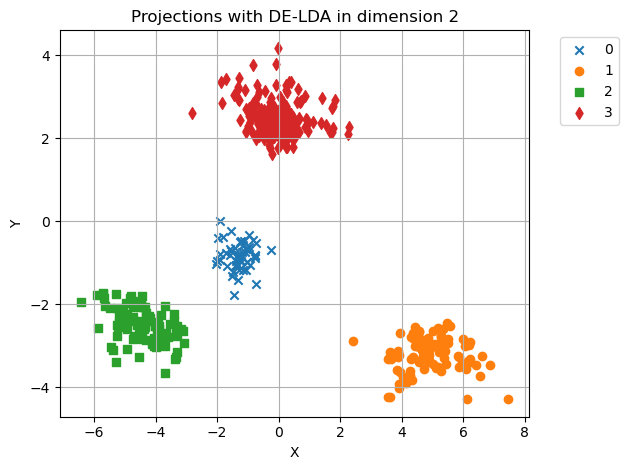

In [27]:
# =============================
# Projection matrix obtained with the DE process
# =============================
rows, cols = features_train.shape
projection_matrix = best_solution.reshape(cols, -1)

# =============================
# Projected data
# =============================
projections_train = features_train @ projection_matrix
deldafe.plot_graphic_de_lda(features_train, labels_train, dimension, projections_train, None)

In [35]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt

# Train SVM classifier with sigmoid kernel on projected data
svm_sigmoid = SVC(kernel='sigmoid', random_state=42, probability=True)
svm_sigmoid.fit(projections_train, labels_train)



,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Saving model

In [ ]:
import joblib
import os

# Create directory if it doesn't exist
model_dir = 'model'
os.makedirs(model_dir, exist_ok=True)

# Save DeepGA_CNN_Model
joblib.dump(DeepGA_CNN_Model, os.path.join(model_dir, 'DeepGA_CNN_Model.joblib'))

# Save projection_matrix
joblib.dump(projection_matrix, os.path.join(model_dir, 'projection_matrix.joblib'))

# Save pruned_models
joblib.dump(svm_sigmoid, os.path.join(model_dir, 'model_SVM.joblib'))

# save features and labels used for training
joblib.dump((projections_train, labels_train), os.path.join(model_dir, 'train_features_labels.joblib'))


print("Models saved successfully to model/")

Models saved successfully to model/
